In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load the clean data
X_train = joblib.load('../models/X_train.pkl')
y_train = joblib.load('../models/y_train.pkl')
feature_names = joblib.load('../models/feature_names.pkl')
label_encoder = joblib.load('../models/label_encoder.pkl')

# Convert y back to original class names for plotting
class_names = label_encoder.inverse_transform(y_train)

# Create a DataFrame for plotting
plot_df = X_train.copy()
plot_df['class'] = class_names

print("Data loaded for EDA!")
print(f"Shape: {plot_df.shape}")
print(f"Classes: {plot_df['class'].unique()}")

Data loaded for EDA!
Shape: (69991, 11)
Classes: <StringArray>
['STAR', 'GALAXY', 'QSO']
Length: 3, dtype: str


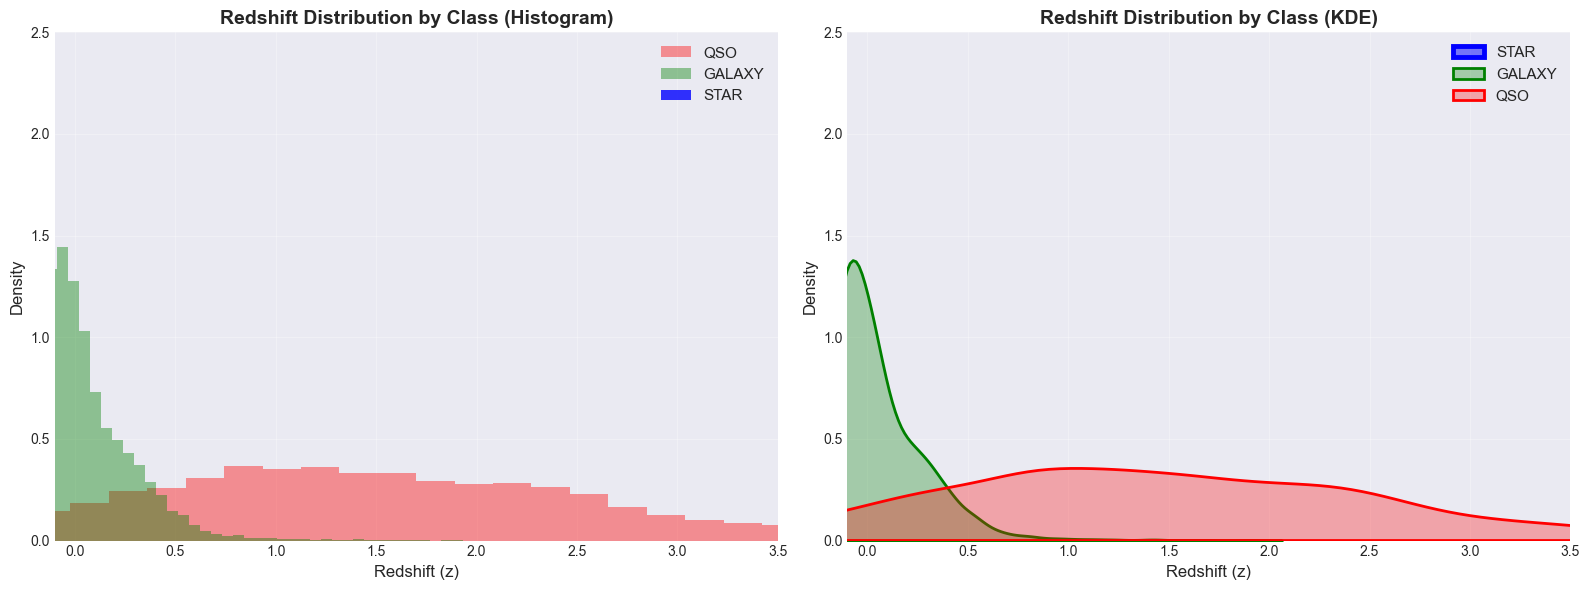

✅ Redshift plots saved!


In [7]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
colors = {'STAR': 'blue', 'GALAXY': 'green', 'QSO': 'red'}

# Create figure with 2 subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Overlapping Histograms 
ax1 = axes[0]

# First plot 
for class_name in ['QSO', 'GALAXY']:
    subset = plot_df[plot_df['class'] == class_name]
    ax1.hist(subset['red_shift'], bins=50, alpha=0.4, 
             label=class_name, color=colors[class_name], density=True)

star_subset = plot_df[plot_df['class'] == 'STAR']
ax1.hist(star_subset['red_shift'], bins=50, alpha=0.8, 
         label='STAR', color='blue', density=True)

ax1.set_xlabel('Redshift (z)', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Redshift Distribution by Class (Histogram)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-0.1, 3.5)
ax1.set_ylim(0, 2.5)

# Plot 2: KDE 
ax2 = axes[1]

for class_name, color in colors.items():
    subset = plot_df[plot_df['class'] == class_name]
    linewidth = 3.5 if class_name == 'STAR' else 2.0 
    alpha = 0.5 if class_name == 'STAR' else 0.3      
    
    sns.kdeplot(data=subset, x='red_shift', label=class_name, color=color, 
                linewidth=linewidth, fill=True, alpha=alpha, ax=ax2)

ax2.set_xlabel('Redshift (z)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Redshift Distribution by Class (KDE)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-0.1, 3.5)
ax2.set_ylim(0, 2.5)

plt.tight_layout()
plt.savefig('../visualizations/redshift_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Redshift plots saved!")

C:\Users\sdas_\AppData\Local\Temp\ipykernel_12572\2821904462.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[row, col_idx].boxplot(plot_data, labels=['STAR', 'GALAXY', 'QSO'],
C:\Users\sdas_\AppData\Local\Temp\ipykernel_12572\2821904462.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[row, col_idx].boxplot(plot_data, labels=['STAR', 'GALAXY', 'QSO'],
C:\Users\sdas_\AppData\Local\Temp\ipykernel_12572\2821904462.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[row, col_idx].boxplot(plot_data, labels=['STAR', 'GALAXY', 'QSO'],
C:\Users\sdas_\AppData\Local\Temp\ipykernel_12572\28

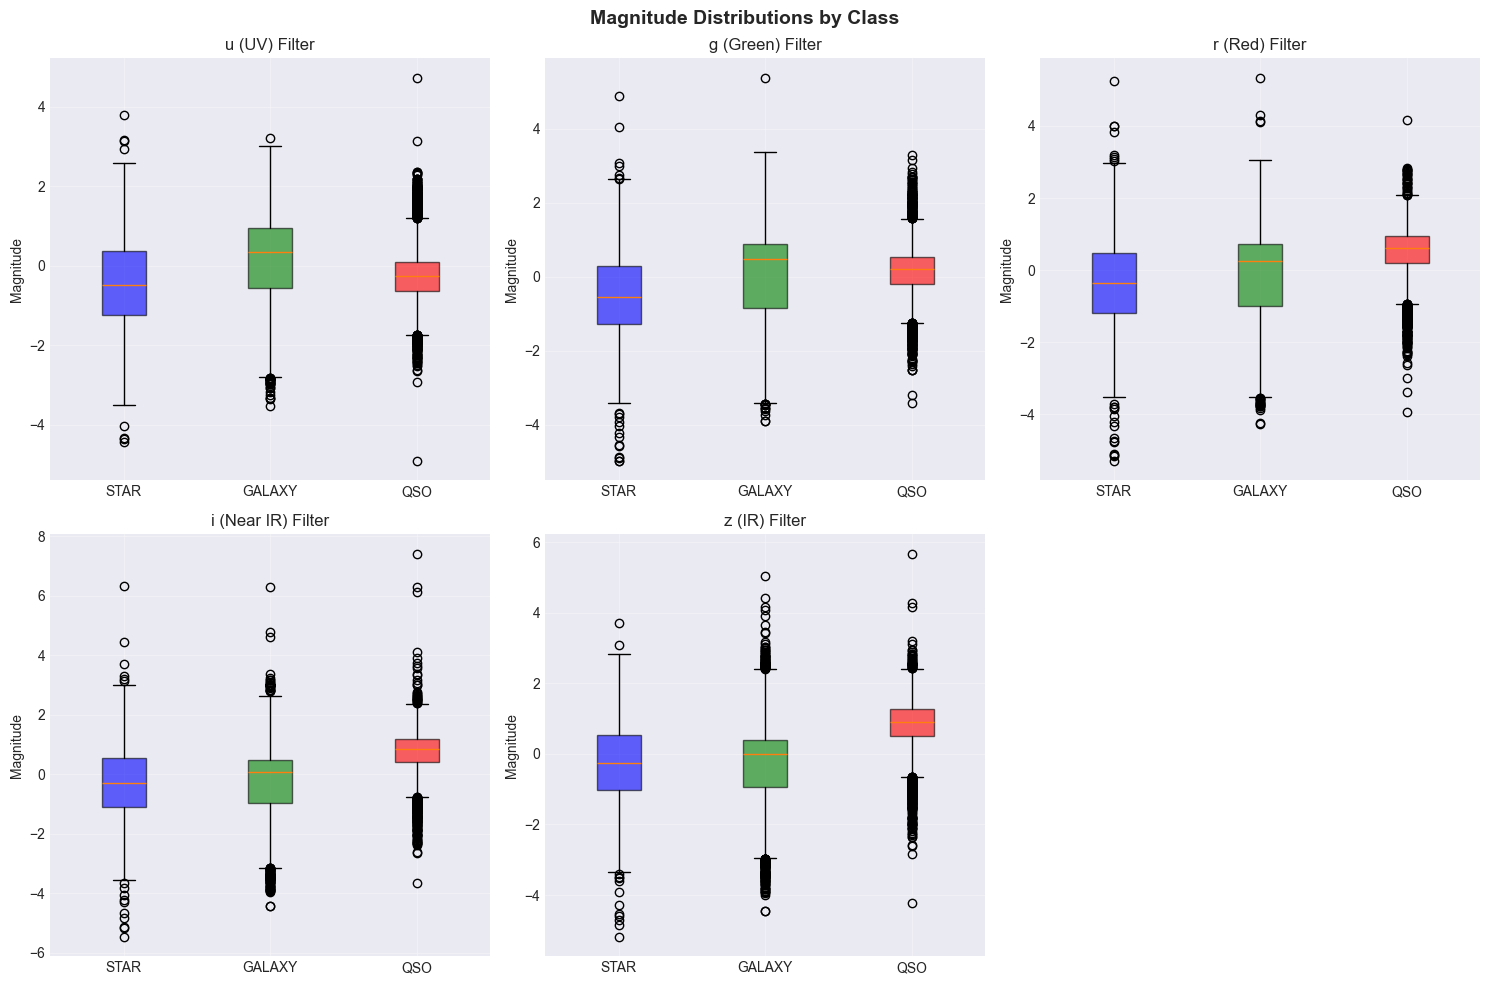

✅ Magnitude boxplots saved to visualizations/


In [8]:
# Create boxplots for all magnitude filters
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
magnitude_cols = ['UV_filter', 'green_filter', 'red_filter', 
                  'near_IR_filter', 'IR_filter']
titles = ['u (UV)', 'g (Green)', 'r (Red)', 'i (Near IR)', 'z (IR)']

for idx, (col, title) in enumerate(zip(magnitude_cols, titles)):
    row, col_idx = idx // 3, idx % 3
    plot_data = [plot_df[plot_df['class'] == c][col] for c in ['STAR', 'GALAXY', 'QSO']]
    
    bp = axes[row, col_idx].boxplot(plot_data, labels=['STAR', 'GALAXY', 'QSO'], 
                                     patch_artist=True)
    
    # Color the boxes
    colors = ['blue', 'green', 'red']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    axes[row, col_idx].set_title(f'{title} Filter')
    axes[row, col_idx].set_ylabel('Magnitude')
    axes[row, col_idx].grid(True, alpha=0.3)

# Hide the empty subplot (6th one)
axes[1, 2].axis('off')

plt.suptitle('Magnitude Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/magnitude_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Magnitude boxplots saved to visualizations/")

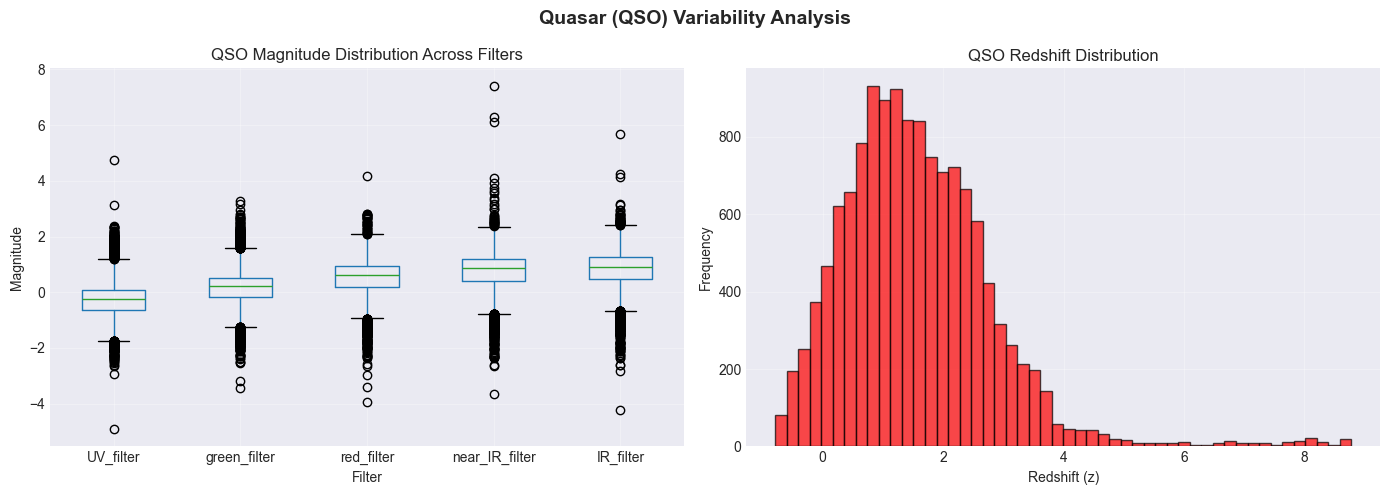

✅ Quasar analysis plots saved to visualizations/


In [10]:
# Focus on quasars only
qso_df = plot_df[plot_df['class'] == 'QSO']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot of all magnitudes for QSO
qso_magnitudes = qso_df[['UV_filter', 'green_filter', 'red_filter', 
                         'near_IR_filter', 'IR_filter']]
qso_magnitudes.boxplot(ax=axes[0])
axes[0].set_title('QSO Magnitude Distribution Across Filters')
axes[0].set_ylabel('Magnitude')
axes[0].set_xlabel('Filter')
axes[0].grid(True, alpha=0.3)

# Redshift distribution of QSO
axes[1].hist(qso_df['red_shift'], bins=50, color='red', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Redshift (z)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('QSO Redshift Distribution')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Quasar (QSO) Variability Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/quasar_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Quasar analysis plots saved to visualizations/")

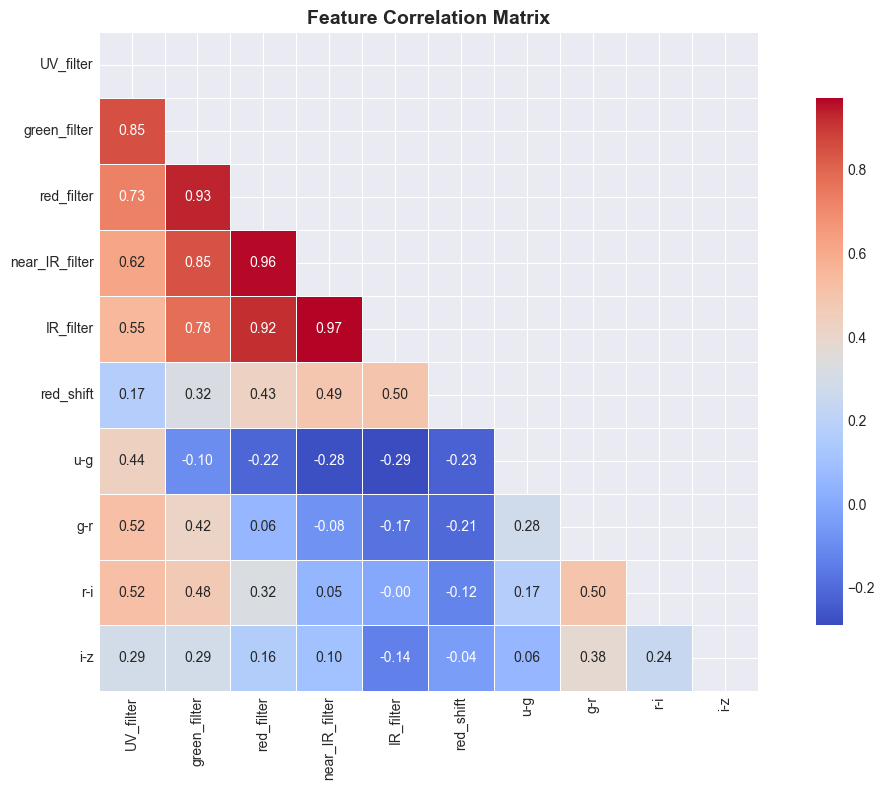

✅ Correlation heatmap saved to visualizations/


In [11]:
# Create refined correlation heatmap
plt.figure(figsize=(12, 8))

# Select features for correlation
corr_features = ['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 
                 'IR_filter', 'red_shift', 'u-g', 'g-r', 'r-i', 'i-z']
corr_matrix = plot_df[corr_features].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Correlation heatmap saved to visualizations/")

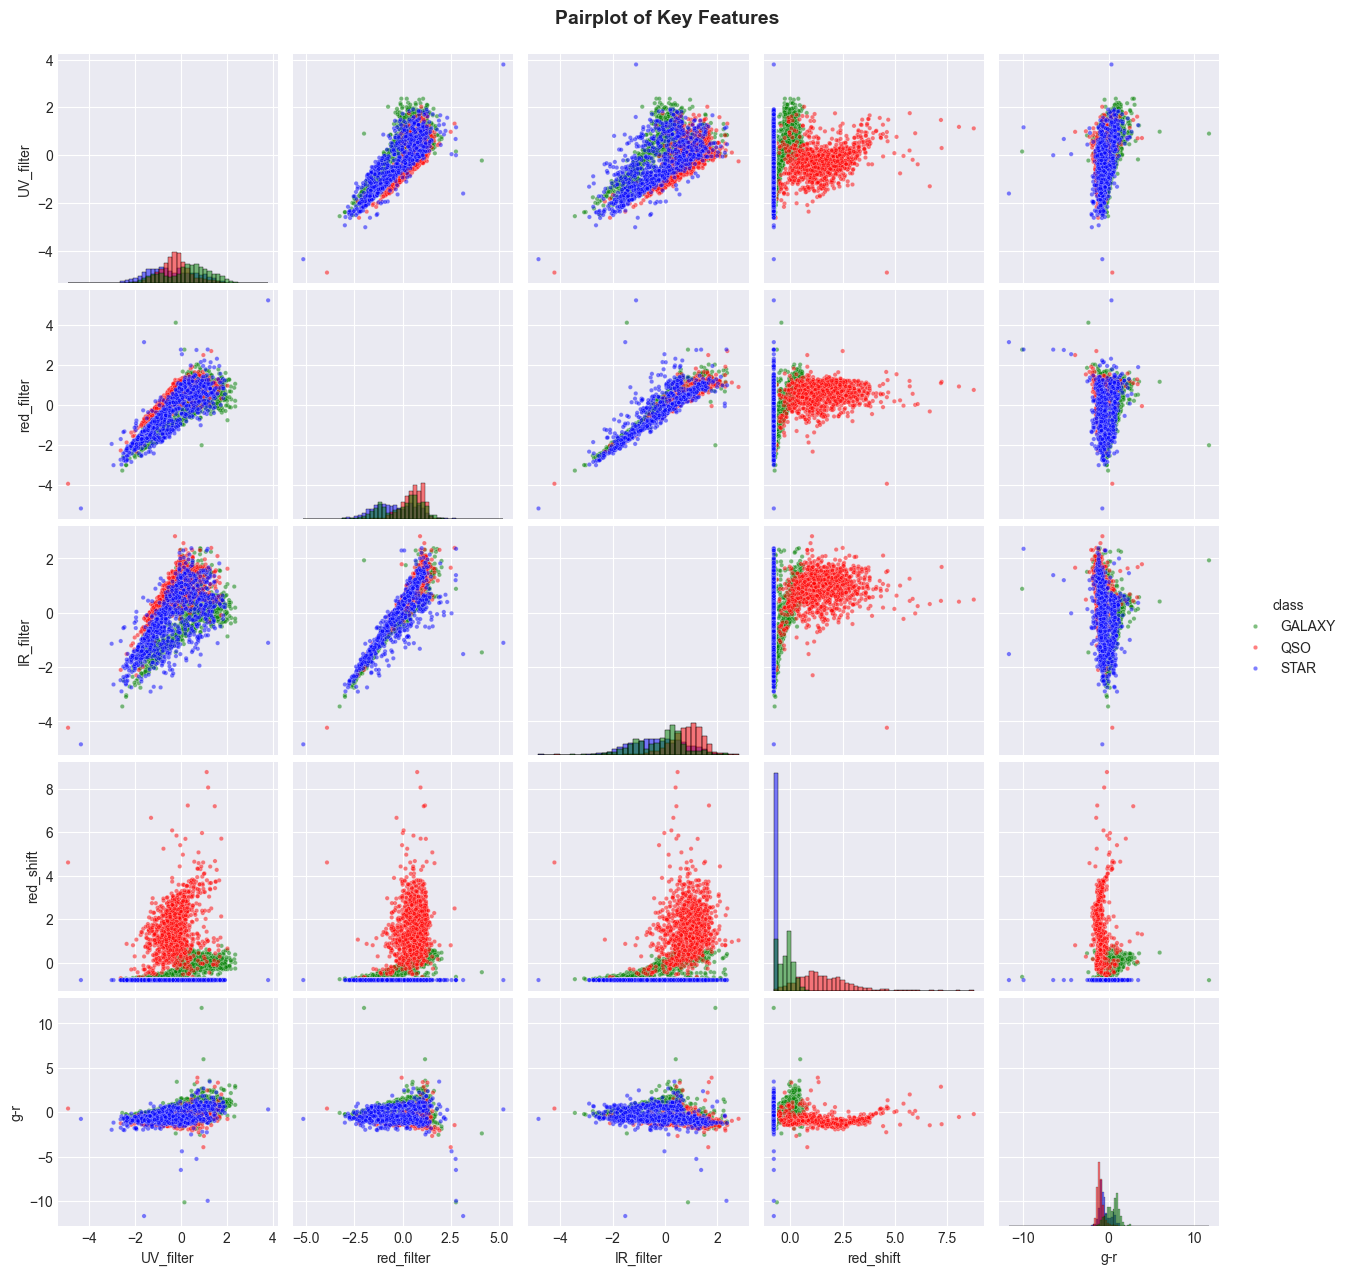

✅ Pairplot saved to visualizations/


In [12]:
# Create pairplot of key features
from sklearn.preprocessing import StandardScaler

# Sample data for pairplot (to avoid memory issues)
sample_df = plot_df.groupby('class').sample(n=1000, random_state=42)

# Select key features
pairplot_features = ['UV_filter', 'red_filter', 'IR_filter', 'red_shift', 'g-r', 'class']

# Create pairplot
g = sns.pairplot(sample_df[pairplot_features], hue='class', 
                 palette={'STAR': 'blue', 'GALAXY': 'green', 'QSO': 'red'},
                 diag_kind='hist', plot_kws={'alpha': 0.5, 's': 10})

g.fig.suptitle('Pairplot of Key Features', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('../visualizations/pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Pairplot saved to visualizations/")

Colors dictionary created: {'STAR': 'blue', 'GALAXY': 'green', 'QSO': 'red'}


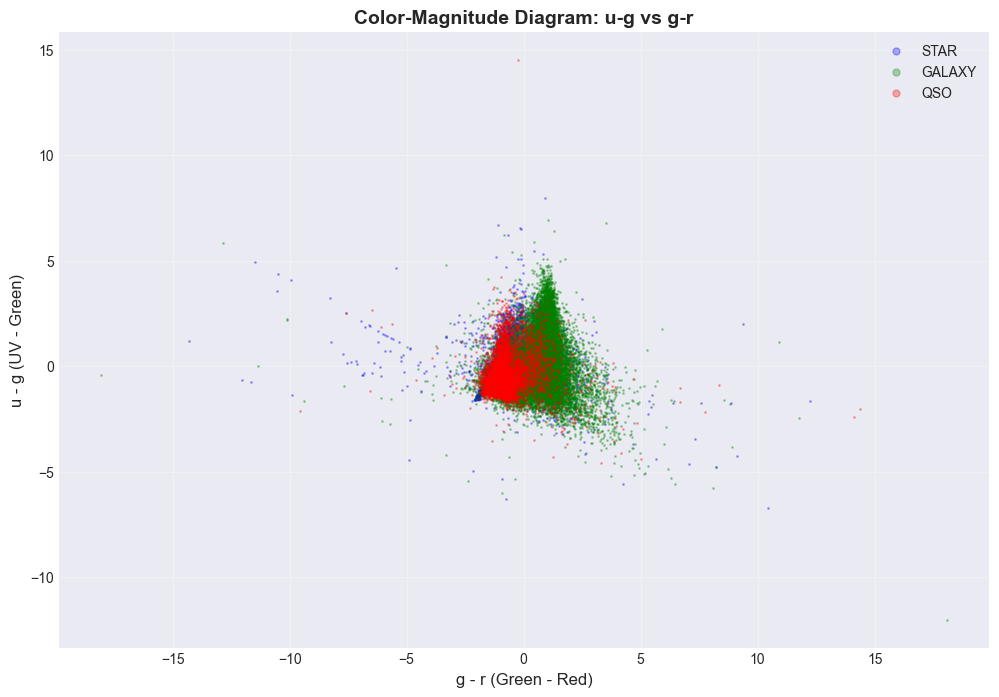

✅ Color-magnitude diagram saved to visualizations/


In [14]:
# Define colors as a dictionary 
colors = {'STAR': 'blue', 'GALAXY': 'green', 'QSO': 'red'}
print("Colors dictionary created:", colors)

# Create color-magnitude diagram (u-g vs g)
plt.figure(figsize=(12, 8))

for class_name, color in colors.items():
    subset = plot_df[plot_df['class'] == class_name]
    plt.scatter(subset['g-r'], subset['u-g'], 
                c=color, label=class_name, alpha=0.3, s=1)

plt.xlabel('g - r (Green - Red)', fontsize=12)
plt.ylabel('u - g (UV - Green)', fontsize=12)
plt.title('Color-Magnitude Diagram: u-g vs g-r', fontsize=14, fontweight='bold')
plt.legend(markerscale=5)
plt.grid(True, alpha=0.3)

plt.savefig('../visualizations/color_magnitude.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Color-magnitude diagram saved to visualizations/")

In [13]:
# Generate summary statistics for your PPT
print("=" * 50)
print("SUMMARY STATISTICS")
print("=" * 50)

# 1. Redshift ranges by class
print("\n1. REDSHIFT RANGES BY CLASS:")
for class_name in ['STAR', 'GALAXY', 'QSO']:
    subset = plot_df[plot_df['class'] == class_name]
    print(f"   {class_name}: min={subset['red_shift'].min():.3f}, "
          f"max={subset['red_shift'].max():.3f}, "
          f"mean={subset['red_shift'].mean():.3f}")

# 2. Filter magnitude overlaps
print("\n2. MAGNITUDE RANGES (showing overlap):")
for filter_name in ['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter']:
    print(f"   {filter_name}: {plot_df[filter_name].min():.2f} - {plot_df[filter_name].max():.2f}")

# 3. Color indices summary
print("\n3. COLOR INDICES SUMMARY:")
color_indices = ['u-g', 'g-r', 'r-i', 'i-z']
for idx in color_indices:
    print(f"   {idx}: mean={plot_df[idx].mean():.3f}, std={plot_df[idx].std():.3f}")

# 4. Class distribution
print("\n4. CLASS DISTRIBUTION:")
class_counts = plot_df['class'].value_counts()
for class_name, count in class_counts.items():
    print(f"   {class_name}: {count} ({count/len(plot_df)*100:.1f}%)")

print("\n" + "=" * 50)

SUMMARY STATISTICS

1. REDSHIFT RANGES BY CLASS:
   STAR: min=-0.794, max=-0.783, mean=-0.789
   GALAXY: min=-0.802, max=1.934, mean=-0.212
   QSO: min=-0.788, max=8.779, mean=1.563

2. MAGNITUDE RANGES (showing overlap):
   UV_filter: -4.92 - 4.74
   green_filter: -4.98 - 5.38
   red_filter: -5.30 - 5.34
   near_IR_filter: -5.47 - 7.42
   IR_filter: -5.19 - 5.67

3. COLOR INDICES SUMMARY:
   u-g: mean=0.000, std=1.000
   g-r: mean=-0.000, std=1.000
   r-i: mean=0.000, std=1.000
   i-z: mean=0.000, std=1.000

4. CLASS DISTRIBUTION:
   GALAXY: 41604 (59.4%)
   STAR: 15115 (21.6%)
   QSO: 13272 (19.0%)

